# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [28]:
# Import the library
!pip install scikit-image
%pip install scikit-image
from PIL import Image
from skimage import data

Note: you may need to restart the kernel to use updated packages.


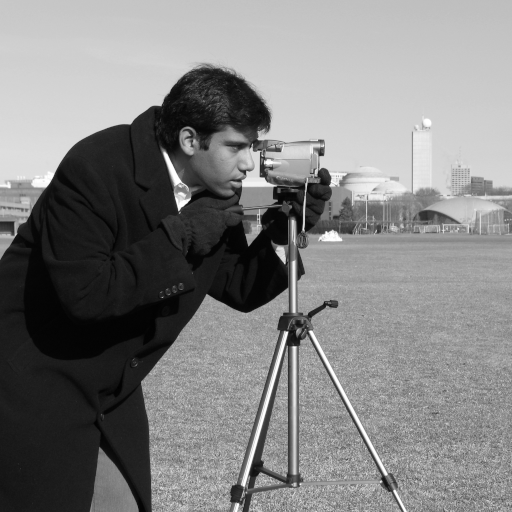

In [29]:
# ── Load image ────────────────────────────────────
cam_array = data.camera()
image = Image.fromarray(cam_array)
image

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [30]:
# Get the size of the image
width, height = image.size

# scaling factors
scale_factor = 2

In [31]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * scale_factor)
new_height = int(height * scale_factor)

# Resize the image using PIL's built-in method
scaled_image = image.resize((new_width, new_height), resample=Image.Resampling.LANCZOS)

In [32]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print(f"Original size: {image.size}")
print(f"Scaled size:   {scaled_image.size}")

Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [33]:
width, height = image.size
cx = 2
cy = 1
new_width = int(width * cx)
new_height = int(height * cy)

In [34]:
stretched_image = image.resize((new_width, new_height), resample=Image.Resampling.LANCZOS)
stretched_image.save("task1_2_stretched.jpg")

In [35]:
print(f"Original size:  {image.size}")
print(f"Stretched size: {stretched_image.size}")

Original size:  (512, 512)
Stretched size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [36]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(120, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")

print(f"Original size: {image.size}")
print(f"Rotated size:  {rotated_image.size}")

Original size: (512, 512)
Rotated size:  (700, 700)


### 3. Shear

In [37]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [38]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = (1, shear_factor, 0, 0, 1, 0)


In [40]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + abs(shear_factor) * height)
new_height = height
sheared_image = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

In [41]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

print(f"Original size: {image.size}")
print(f"Sheared size:  {sheared_image.size}")

Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [42]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np
img_array = np.array(image)
negative_array = 255 - img_array
negative_image_np = Image.fromarray(negative_array)

In [ ]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_image_ops = ImageOps.invert(image)

In [43]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
img_array = np.array(image, dtype=float)
c = 255.0 / np.log(1 + 255)
log_transformed_array = c * np.log(1 + img_array)
log_image = Image.fromarray(np.uint8(log_transformed_array))


# Apply the log transformation to each pixel
import math
log_image = image.point(lambda r: int(c * math.log(1 + r)))

In [45]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
c_gamma = 255.0 / (255.0 ** gamma)
gamma_corrected_image = image.point(lambda r: int(c_gamma * (r ** gamma)))

In [46]:
import matplotlib.pyplot as plt

processed_images = [
    (image, "Original"),
    (negative_image_ops, "Negative (ImageOps)"),
    (log_image, "Log Transformed"),
    (gamma_corrected_image, f"Gamma Corrected (γ={gamma})")
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (img, title) in zip(axes, processed_images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off') 

plt.tight_layout()
plt.show()


NameError: name 'negative_image_ops' is not defined